In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.options.display.max_columns = None

In [2]:
#mouting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd drive/MyDrive/TFG/oulad

/content/drive/MyDrive/TFG/oulad


In [ ]:
df_final = pd.read_csv('df_v2.csv')

In [ ]:
df_final.head()

,Unnamed: 0,code_module,code_presentation,id_student,date_registration,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,tma_mean_score,cma_mean_score,exam_mean_score,mean_score,total_clicks,clicks_from_dataplus,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_page,clicks_from_glossary,clicks_from_ouelluminate,clicks_from_dualpane,clicks_from_folder,clicks_from_questionnaire,clicks_from_htmlactivity,clicks_from_sharedsubpage,clicks_from_repeatactivity,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day
0,0,AAA,2013J,11391,-159.0,268.0,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,NaN,NaN,82.0,934.0,0.0,193.0,138.0,553.0,13.0,32.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.765306,82.4,82.4,268,0.017781
1,1,AAA,2013J,28400,-53.0,268.0,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,NaN,NaN,66.4,1435.0,10.0,417.0,324.0,537.0,12.0,87.0,48.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.337209,65.4,65.4,268,0.012452
2,2,AAA,2013J,30268,-92.0,12.0,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,NaN,0.0,281.0,0.0,126.0,59.0,66.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.697368,0.0,0.0,268,0.013796
3,3,AAA,2013J,31604,-52.0,268.0,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,NaN,NaN,76.0,2158.0,2.0,634.0,432.0,836.0,19.0,144.0,90.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.254902,76.3,76.3,268,0.012145
4,4,AAA,2013J,32885,-176.0,268.0,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,NaN,NaN,54.4,1034.0,0.0,194.0,204.0,494.0,45.0,79.0,14.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.937500,55.0,55.0,268,0.010961


In [ ]:
df_final.drop(['tma_mean_score', 'cma_mean_score', 'exam_mean_score'], axis=1, inplace=True)

In [ ]:
df_final['final_grade'] = df_final[['exam_grade', 'continuous_grade']].mean(axis=1)

In [ ]:
df_final.imd_band.value_counts()

20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Name: imd_band, dtype: int64

In [ ]:
df_final['imd_band'] = df_final['imd_band'].replace(['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'], [5, 15, 25, 35, 45, 55, 65, 75, 85, 95])

In [ ]:
df_final.imd_band.value_counts()

25.0    3654
35.0    3539
15.0    3516
5.0     3311
45.0    3256
55.0    3124
65.0    2905
75.0    2879
85.0    2762
95.0    2536
Name: imd_band, dtype: int64

In [ ]:
corr = df_final.corr()
corr

,Unnamed: 0,id_student,date_registration,date_unregistration,imd_band,num_of_prev_attempts,studied_credits,mean_score,total_clicks,clicks_from_dataplus,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_page,clicks_from_glossary,clicks_from_ouelluminate,clicks_from_dualpane,clicks_from_folder,clicks_from_questionnaire,clicks_from_htmlactivity,clicks_from_sharedsubpage,clicks_from_repeatactivity,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day,final_grade
Unnamed: 0,1.000000,0.023362,0.073668,0.074583,0.007473,-0.039796,-0.120323,0.072536,0.198716,0.184624,-0.030641,0.090744,0.302898,-0.010622,0.208257,0.024026,-0.015034,0.061240,0.130463,0.185171,0.301560,0.006176,0.048527,0.186598,0.214458,0.242689,0.275315,-0.073049,0.009084,0.223757,0.100618,0.100772,0.153012,0.211081,0.102039
id_student,0.023362,1.000000,0.011186,0.000783,0.027996,0.011473,-0.003868,0.016341,0.036599,0.021387,0.037913,0.040698,0.022107,0.020187,0.039906,0.036671,0.028466,0.024549,0.019838,0.004359,-0.005465,0.005788,0.001252,0.008415,-0.008823,0.012368,0.009168,-0.007471,-0.002421,0.017937,0.014969,0.013931,0.017360,0.015804,0.014634
date_registration,0.073668,0.011186,1.000000,0.166784,0.023103,-0.024884,-0.089228,0.118912,0.007184,0.003329,-0.013021,-0.018654,0.028204,0.013366,-0.002754,0.002790,-0.020869,-0.031194,0.008969,0.015329,0.020166,-0.014890,0.029884,-0.003465,-0.010953,-0.000542,0.010111,0.002169,-0.002382,0.116439,0.076980,0.078037,-0.021842,0.120589,0.078551
date_unregistration,0.074583,0.000783,0.166784,1.000000,0.077671,-0.032437,-0.223464,0.678433,0.365111,0.133805,0.212600,0.335858,0.291598,0.219420,0.305574,0.233242,0.106667,0.173732,0.178771,0.250523,0.139937,0.040566,0.056605,0.130488,0.133168,0.161382,0.063963,0.014812,0.002312,0.487346,0.679374,0.654689,0.090499,0.478794,0.675722
imd_band,0.007473,0.027996,0.023103,0.077671,1.000000,-0.037342,-0.042749,0.125001,0.085723,0.037412,0.059893,0.081070,0.062632,0.040108,0.077294,0.063829,0.046636,0.042606,0.067193,0.046737,0.029703,0.012562,0.020305,0.037762,0.020872,0.032455,0.001731,-0.009458,-0.007026,0.080283,0.146499,0.139469,0.022622,0.078021,0.144798
num_of_prev_attempts,-0.039796,0.011473,-0.024884,-0.032437,-0.037342,1.000000,0.181729,-0.051721,-0.069351,-0.025430,-0.041498,-0.060666,-0.055625,-0.042351,-0.036536,-0.044620,0.005458,-0.018042,-0.053048,-0.053267,-0.020766,-0.006095,0.010844,-0.032339,-0.011105,-0.028280,-0.023939,-0.003876,-0.003150,-0.068314,-0.103353,-0.112233,-0.066306,-0.062444,-0.109304
studied_credits,-0.120323,-0.003868,-0.089228,-0.223464,-0.042749,0.181729,1.000000,-0.153607,-0.036678,0.000144,-0.030235,-0.027523,-0.039893,-0.037445,0.017062,-0.032982,-0.007009,-0.020356,-0.072548,-0.007647,0.028021,-0.011269,0.006978,-0.014222,0.030053,0.006748,0.040638,-0.000565,0.010573,-0.127341,-0.167167,-0.161048,-0.020596,-0.125495,-0.166245
mean_score,0.072536,0.016341,0.118912,0.678433,0.125001,-0.051721,-0.153607,1.000000,0.437951,0.163305,0.286020,0.405854,0.327808,0.240591,0.358261,0.292083,0.107973,0.165212,0.227880,0.293334,0.198087,0.047974,0.089581,0.163986,0.129125,0.202237,0.092669,0.033212,0.006881,0.535047,0.765529,0.732167,0.029653,0.534141,0.758558
total_clicks,0.198716,0.036599,0.007184,0.365111,0.085723,-0.069351,-0.036678,0.437951,1.000000,0.549720,0.707354,0.880836,0.798450,0.329102,0.766710,0.554698,0.116128,0.271354,0.338685,0.657038,0.574373,0.075634,0.242233,0.449135,0.344429,0.598870,0.273478,0.029075,0.023337,0.549746,0.546335,0.542907,0.050936,0.545955,0.551855
clicks_from_dataplus,0.184624,0.021387,0.003329,0.133805,0.037412,-0.025430,0.000144,0.163305,0.549720,1.000000,0.231233,0.402731,0.641998,0.069436,0.475818,0.277446,-0.053117,0.076577,0.081032,0.335444,0.581349,0.003505,0.175488,0.487181,0.276637,0.778716,0.302356,-0.011675,-0.00

In [ ]:
from sklearn.linear_model import LinearRegression

df_nans_imd = df_final.dropna(axis=0, subset=['imd_band', 'final_grade'])

X = df_nans_imd[['final_grade']]
y = df_nans_imd['imd_band']


missing_entries = df_final['imd_band'].isnull()
imd_missing = pd.DataFrame(df_final['final_grade'][missing_entries])

# fit a linear model
lm = LinearRegression().fit(X, y)
# use fitted model and tip values to predict missing total_bill
#pred_imd = lm.predict(imd_missing)

In [ ]:
lm.predict(np.array([9.0]).reshape(1, -1))[0]

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:420: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


43.283587875954375

In [ ]:
df_final.loc[pd.isna(df_final["imd_band"]), "imd_band"] = df_final[pd.isna(df_final["imd_band"])]["final_grade"].apply(
    lambda x: lm.predict(np.array([x]).reshape(1, -1))[0])

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:420: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:420: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:420: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:420: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:420: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:420: UserWarning: X does not have valid feature names, 

In [ ]:
df_final.imd_band.value_counts()

25.000000    3654
35.000000    3539
15.000000    3516
5.000000     3311
45.000000    3256
             ... 
49.214069       1
48.560948       1
49.296825       1
42.553664       1
52.729729       1
Name: imd_band, Length: 807, dtype: int64

In [ ]:
def round_to_nearest_five(num):
    """
    Rounds the given number to the nearest number ending in 5 if the number does not already end in 5.
    """
    if num % 10 == 5:
        return num
    quotient, remainder = divmod(num, 10)
    if remainder < 3:
        return quotient * 10 + 5
    else:
        return (quotient + 1) * 10 + 5


In [ ]:
df_final.imd_band=df_final.imd_band.apply(lambda x: round_to_nearest_five(x))

In [ ]:
df_final.imd_band.value_counts()

55.0    3936
25.0    3654
35.0    3539
15.0    3516
45.0    3432
5.0     3311
65.0    3028
75.0    2879
85.0    2762
95.0    2536
Name: imd_band, dtype: int64

In [ ]:
df_final

,Unnamed: 0,code_module,code_presentation,id_student,date_registration,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_clicks,clicks_from_dataplus,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_page,clicks_from_glossary,clicks_from_ouelluminate,clicks_from_dualpane,clicks_from_folder,clicks_from_questionnaire,clicks_from_htmlactivity,clicks_from_sharedsubpage,clicks_from_repeatactivity,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day,final_grade
0,0,AAA,2013J,11391,-159.0,268.0,M,East Anglian Region,HE Qualification,95.0,55<=,0,240,N,Pass,82.000000,934.0,0.0,193.0,138.0,553.0,13.0,32.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.765306,82.40,82.40,268,0.017781,82.40
1,1,AAA,2013J,28400,-53.0,268.0,F,Scotland,HE Qualification,25.0,35-55,0,60,N,Pass,66.400000,1435.0,10.0,417.0,324.0,537.0,12.0,87.0,48.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.337209,65.40,65.40,268,0.012452,65.40
2,2,AAA,2013J,30268,-92.0,12.0,F,North Western Region,A Level or Equivalent,35.0,35-55,0,60,Y,Withdrawn,0.000000,281.0,0.0,126.0,59.0,66.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.697368,0.00,0.00,268,0.013796,0.00
3,3,AAA,2013J,31604,-52.0,268.0,F,South East Region,A Level or Equivalent,55.0,35-55,0,60,N,Pass,76.000000,2158.0,2.0,634.0,432.0,836.0,19.0,144.0,90.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.254902,76.30,76.30,268,0.012145,76.30
4,4,AAA,2013J,32885,-176.0,268.0,F,West Midlands Region,Lower Than A Level,55.0,0-35,0,60,N,Pass,54.400000,1034.0,0.0,194.0,204.0,494.0,45.0,79.0,14.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.937500,55.00,55.00,268,0.010961,55.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,32588,GGG,2014J,2640965,-4.0,269.0,F,Wales,Lower Than A Level,15.0,0-35,0,30,N,Fail,0.000000,41.0,0.0,0.0,22.0,6.0,4.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.157895,0.00,0.00,269,0.008022,0.00
32589,32589,GGG,2014J,2645731,-23.0,269.0,F,East Anglian Region,Lower Than A Level,45.0,35-55,0,30,N,Distinction,88.111111,893.0,0.0,65.0,167.0,348.0,109.0,47.0,0.0,0.0,0.0,0.0,152.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.767932,87.23,87.23,269,0.014007,87.23
32590,32590,GGG,2014J,2648187,-129.0,269.0,F,South Region,A Level or Equivalent,25.0,0-35,0,30,Y,Pass,76.666667,312.0,0.0,0.0,63.0,79.0,19.0,20.0,0.0,0.0,0.0,0.0,130.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.888889,75.90,75.90,269,0.010739,75.90
32591,32591,GGG,2014J,2679821,-49.0,101.0,F,South East Region,Lower Than A Level,95.0,35-55,0,30,N,Withdrawn,91.500000,275.0,0.0,118.0,65.0,40.0,9.0,12.0,0.0,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.508197,20.13,20.13,269,0.016759,20.13


In [ ]:
df_final['gender'] = df_final['gender'].map({'M': 0,'F': 1})

In [ ]:
df_final.region.value_counts()

Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: region, dtype: int64

In [ ]:
df_final.highest_education.value_counts()
#pasar de 0 a 5

A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: highest_education, dtype: int64

In [ ]:
df_final.age_band.value_counts() 
#values?

0-35     22944
35-55     9433
55<=       216
Name: age_band, dtype: int64

In [ ]:
df_final.disability.value_counts() 

N    29429
Y     3164
Name: disability, dtype: int64

In [ ]:
df_final['disability'] = df_final['disability'].map({'N': 0,'Y': 1})

In [ ]:
df_final.final_result.value_counts()

Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: final_result, dtype: int64

In [ ]:
df_final.columns

Index(['Unnamed: 0', 'code_module', 'code_presentation', 'id_student',
       'date_registration', 'date_unregistration', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'mean_score',
       'total_clicks', 'clicks_from_dataplus', 'clicks_from_forumng',
       'clicks_from_homepage', 'clicks_from_oucontent', 'clicks_from_resource',
       'clicks_from_subpage', 'clicks_from_url', 'clicks_from_externalquiz',
       'clicks_from_oucollaborate', 'clicks_from_ouwiki', 'clicks_from_quiz',
       'clicks_from_page', 'clicks_from_glossary', 'clicks_from_ouelluminate',
       'clicks_from_dualpane', 'clicks_from_folder',
       'clicks_from_questionnaire', 'clicks_from_htmlactivity',
       'clicks_from_sharedsubpage', 'clicks_from_repeatactivity',
       'mean_clicks', 'continuous_grade', 'exam_grade',
       'module_presentation_length', 'mean_clicks_per_day', 'final_grade'],
      dtype='

<AxesSubplot:ylabel='Density'>

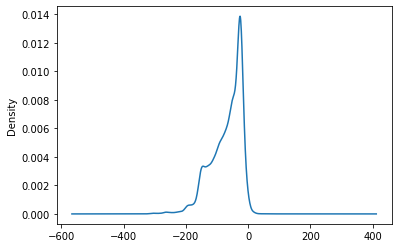

In [ ]:
df_final['date_registration'].plot(kind='kde')

<AxesSubplot:ylabel='Density'>

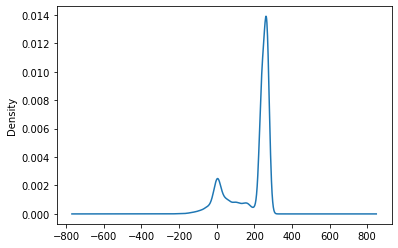

In [ ]:
df_final['date_unregistration'].plot(kind='kde')

<AxesSubplot:ylabel='Density'>

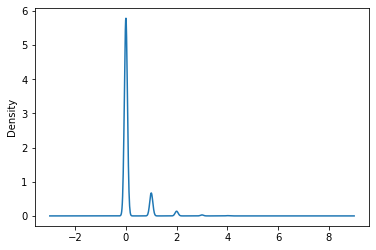

In [ ]:
df_final['num_of_prev_attempts'].plot(kind='kde')

<AxesSubplot:ylabel='Density'>

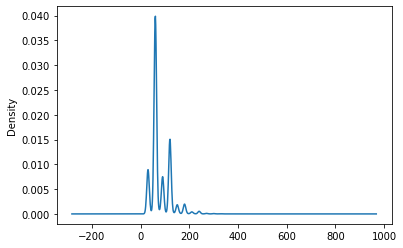

In [ ]:
df_final.studied_credits.plot(kind='kde')

In [ ]:
df_final.studied_credits.mean()

79.75869051636855

In [ ]:
df_final.studied_credits.value_counts()

60     16751
120     6328
30      3749
90      3144
180      830
       ...  
480        1
655        1
390        1
235        1
430        1
Name: studied_credits, Length: 61, dtype: int64

<AxesSubplot:ylabel='Density'>

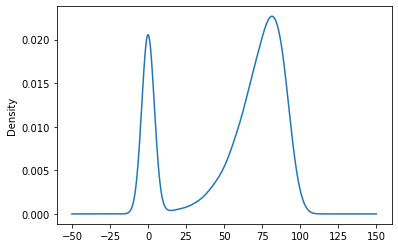

In [ ]:
df_final['mean_score'].plot(kind='kde')

In [ ]:
df_final.mean_score.min()

0.0

<AxesSubplot:ylabel='Density'>

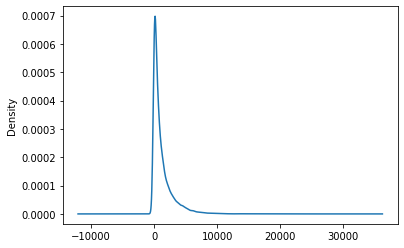

In [ ]:
df_final['total_clicks'].plot(kind='kde')

<AxesSubplot:ylabel='Density'>

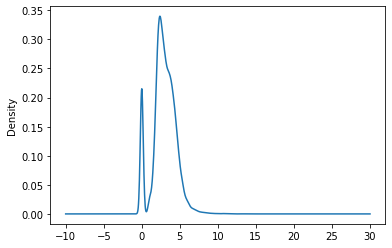

In [ ]:
df_final['mean_clicks'].plot(kind='kde')

<AxesSubplot:ylabel='Density'>

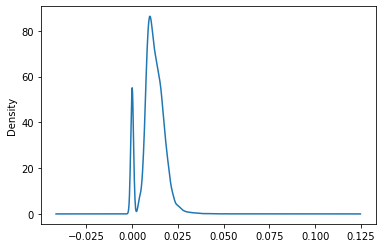

In [ ]:
df_final['mean_clicks_per_day'].plot(kind='kde')

<AxesSubplot:ylabel='Density'>

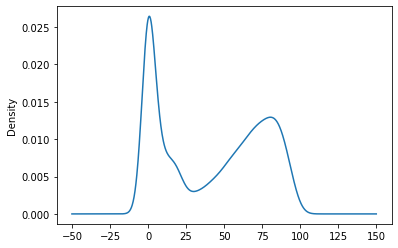

In [ ]:
df_final['final_grade'].plot(kind='kde')